In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

INPUT_DIR = Path('input')

# Load data
customers = pd.read_csv(INPUT_DIR / 'customers.csv')
orders = pd.read_csv(INPUT_DIR / 'orders.csv', parse_dates=['order_date'])
order_items = pd.read_csv(INPUT_DIR / 'order_items.csv')
products = pd.read_csv(INPUT_DIR / 'products.csv')
geography = pd.read_csv(INPUT_DIR / 'geography.csv')
web_traffic = pd.read_csv(INPUT_DIR / 'web_traffic.csv', parse_dates=['date'])

# Merge datasets
orders = orders.merge(customers[['customer_id', 'age_group', 'acquisition_channel']], on='customer_id', how='left')
orders = orders.merge(geography[['zip', 'region']], left_on='zip', right_on='zip', how='left')

# Add time features
orders['year'] = orders['order_date'].dt.year
orders['month'] = orders['order_date'].dt.month
orders['year_month'] = orders['order_date'].dt.to_period('M')
orders['quarter'] = orders['order_date'].dt.quarter

# Merge order_items with products
order_items = order_items.merge(products[['product_id', 'category', 'price']], on='product_id', how='left')
order_items = order_items.merge(orders[['order_id', 'customer_id', 'order_date', 'age_group', 'region', 'order_source', 'month', 'year']], on='order_id', how='left')

# Filter delivered orders
orders_delivered = orders[orders['order_status'] == 'delivered'].copy()
order_items_delivered = order_items.merge(orders_delivered[['order_id']], on='order_id', how='inner')

print('✅ Data loaded successfully')
print(f'Customers: {len(customers):,}')
print(f'Orders (delivered): {len(orders_delivered):,}')
print(f'Order Items: {len(order_items_delivered):,}')
print(f'Date range: {orders_delivered["order_date"].min().date()} → {orders_delivered["order_date"].max().date()}')

✅ Data loaded successfully
Customers: 121,930
Orders (delivered): 516,716
Order Items: 570,887
Date range: 2012-07-04 → 2022-12-31


# 1️⃣ AGE GROUP PURCHASE BEHAVIOR
**Objective:** Identify which age cohorts are most valuable and how their purchasing intensity varies

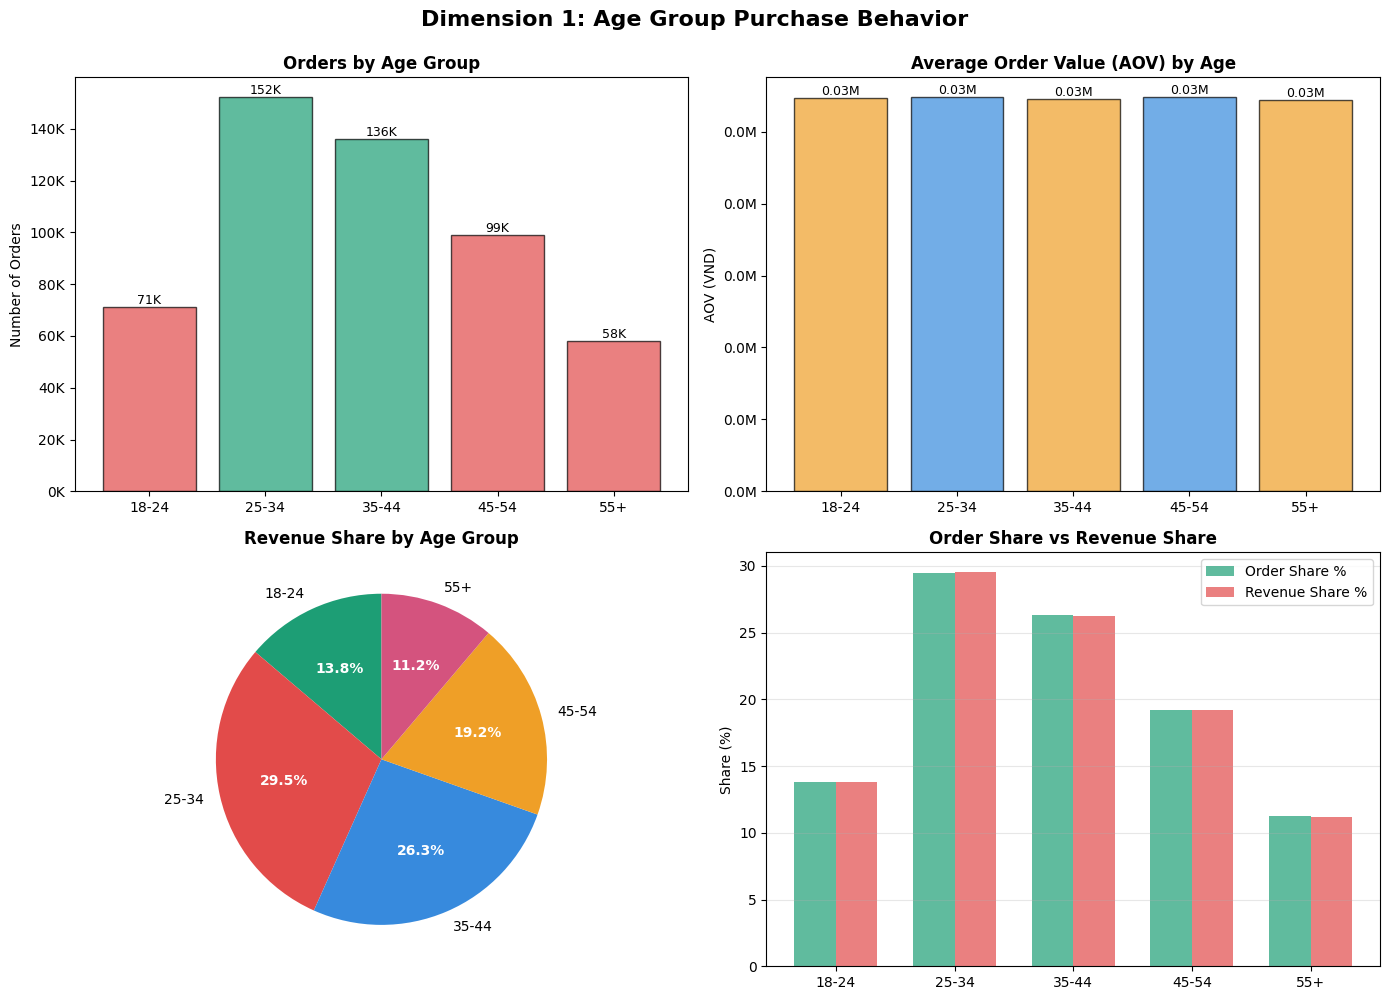


📊 DIMENSION 1: AGE GROUP PURCHASE BEHAVIOR - METRICS CALCULATIONS

Metrics computed:
--------------------------------------------------------------------------------

1. Order Count
   Formula: COUNT(DISTINCT order_id) GROUP BY age_group
   Meaning: Total number of unique orders per age group

2. Total Quantity
   Formula: SUM(quantity) GROUP BY age_group
   Meaning: Total items ordered per age group

3. Total Revenue
   Formula: SUM(price × quantity) GROUP BY age_group
   Meaning: Total revenue generated from each age group

4. Average Order Value (AOV)
   Formula: Total Revenue / Order Count
   Meaning: Average spending per order for each age group

5. Average Items Per Order
   Formula: Total Quantity / Order Count
   Meaning: Average number of items purchased per order

6. Revenue Share %
   Formula: (Revenue of age_group / Total Revenue) × 100
   Meaning: What percentage of total revenue comes from each age group

7. Order Share %
   Formula: (Order Count of age_group / Total Ord

In [6]:
# Dimension 1: Age Group Purchase Behavior
# Define age group order
age_order = ['18-24', '25-34', '35-44', '45-54', '55+']

# Calculate metrics by age group
age_metrics = order_items_delivered.groupby('age_group').agg(
    order_count = ('order_id', 'nunique'),
    quantity = ('quantity', 'sum'),
    revenue = ('price', lambda x: (x * order_items_delivered.loc[x.index, 'quantity']).sum())
).reset_index()

age_metrics['avg_order_value'] = age_metrics['revenue'] / age_metrics['order_count']
age_metrics['avg_items_per_order'] = age_metrics['quantity'] / age_metrics['order_count']
age_metrics['revenue_share_%'] = (age_metrics['revenue'] / age_metrics['revenue'].sum()) * 100
age_metrics['order_share_%'] = (age_metrics['order_count'] / age_metrics['order_count'].sum()) * 100

# Sort by age
age_metrics['age_group'] = pd.Categorical(age_metrics['age_group'], categories=age_order, ordered=True)
age_metrics = age_metrics.sort_values('age_group').reset_index(drop=True)

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Dimension 1: Age Group Purchase Behavior', fontsize=16, fontweight='bold', y=0.995)

# Plot 1: Order Count by Age
ax1 = axes[0, 0]
colors = ['#1D9E75' if x > age_metrics['order_count'].median() else '#E24B4A' for x in age_metrics['order_count']]
ax1.bar(age_metrics['age_group'], age_metrics['order_count'], color=colors, alpha=0.7, edgecolor='black')
ax1.set_title('Orders by Age Group', fontweight='bold')
ax1.set_ylabel('Number of Orders')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x/1e6:.1f}M' if x >= 1e6 else f'{x/1e3:.0f}K'))
for i, (age, val) in enumerate(zip(age_metrics['age_group'], age_metrics['order_count'])):
    ax1.text(i, val, f'{val/1e6:.2f}M' if val >= 1e6 else f'{val/1e3:.0f}K', ha='center', va='bottom', fontsize=9)

# Plot 2: AOV by Age
ax2 = axes[0, 1]
colors = ['#378ADD' if x > age_metrics['avg_order_value'].median() else '#EF9F27' for x in age_metrics['avg_order_value']]
ax2.bar(age_metrics['age_group'], age_metrics['avg_order_value'], color=colors, alpha=0.7, edgecolor='black')
ax2.set_title('Average Order Value (AOV) by Age', fontweight='bold')
ax2.set_ylabel('AOV (VND)')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x/1e6:.1f}M'))
for i, (age, val) in enumerate(zip(age_metrics['age_group'], age_metrics['avg_order_value'])):
    ax2.text(i, val, f'{val/1e6:.2f}M', ha='center', va='bottom', fontsize=9)

# Plot 3: Revenue Share %
ax3 = axes[1, 0]
colors_pie = ['#1D9E75', '#E24B4A', '#378ADD', '#EF9F27', '#D4537E']
wedges, texts, autotexts = ax3.pie(age_metrics['revenue_share_%'], labels=age_metrics['age_group'], autopct='%1.1f%%',
                                     colors=colors_pie, startangle=90)
ax3.set_title('Revenue Share by Age Group', fontweight='bold')
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

# Plot 4: Order Share % vs Revenue Share %
ax4 = axes[1, 1]
x = np.arange(len(age_metrics))
width = 0.35
ax4.bar(x - width/2, age_metrics['order_share_%'], width, label='Order Share %', color='#1D9E75', alpha=0.7)
ax4.bar(x + width/2, age_metrics['revenue_share_%'], width, label='Revenue Share %', color='#E24B4A', alpha=0.7)
ax4.set_title('Order Share vs Revenue Share', fontweight='bold')
ax4.set_ylabel('Share (%)')
ax4.set_xticks(x)
ax4.set_xticklabels(age_metrics['age_group'])
ax4.legend()
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("📊 DIMENSION 1: AGE GROUP PURCHASE BEHAVIOR - METRICS CALCULATIONS")
print("="*80)
print("\nMetrics computed:")
print("-" * 80)
print("\n1. Order Count")
print("   Formula: COUNT(DISTINCT order_id) GROUP BY age_group")
print("   Meaning: Total number of unique orders per age group")
print()
print("2. Total Quantity")
print("   Formula: SUM(quantity) GROUP BY age_group")
print("   Meaning: Total items ordered per age group")
print()
print("3. Total Revenue")
print("   Formula: SUM(price × quantity) GROUP BY age_group")
print("   Meaning: Total revenue generated from each age group")
print()
print("4. Average Order Value (AOV)")
print("   Formula: Total Revenue / Order Count")
print("   Meaning: Average spending per order for each age group")
print()
print("5. Average Items Per Order")
print("   Formula: Total Quantity / Order Count")
print("   Meaning: Average number of items purchased per order")
print()
print("6. Revenue Share %")
print("   Formula: (Revenue of age_group / Total Revenue) × 100")
print("   Meaning: What percentage of total revenue comes from each age group")
print()
print("7. Order Share %")
print("   Formula: (Order Count of age_group / Total Order Count) × 100")
print("   Meaning: What percentage of total orders come from each age group")
print("\n" + "-" * 80)
print("📈 Summary Table:")
print("-" * 80)
print(age_metrics[['age_group', 'order_count', 'quantity', 'revenue', 'avg_order_value', 'order_share_%', 'revenue_share_%']].to_string(index=False))
print("="*80 + "\n")

# 2️⃣ AGE × CATEGORY MATRIX
**Objective:** Understand product affinity—which age groups prefer which categories

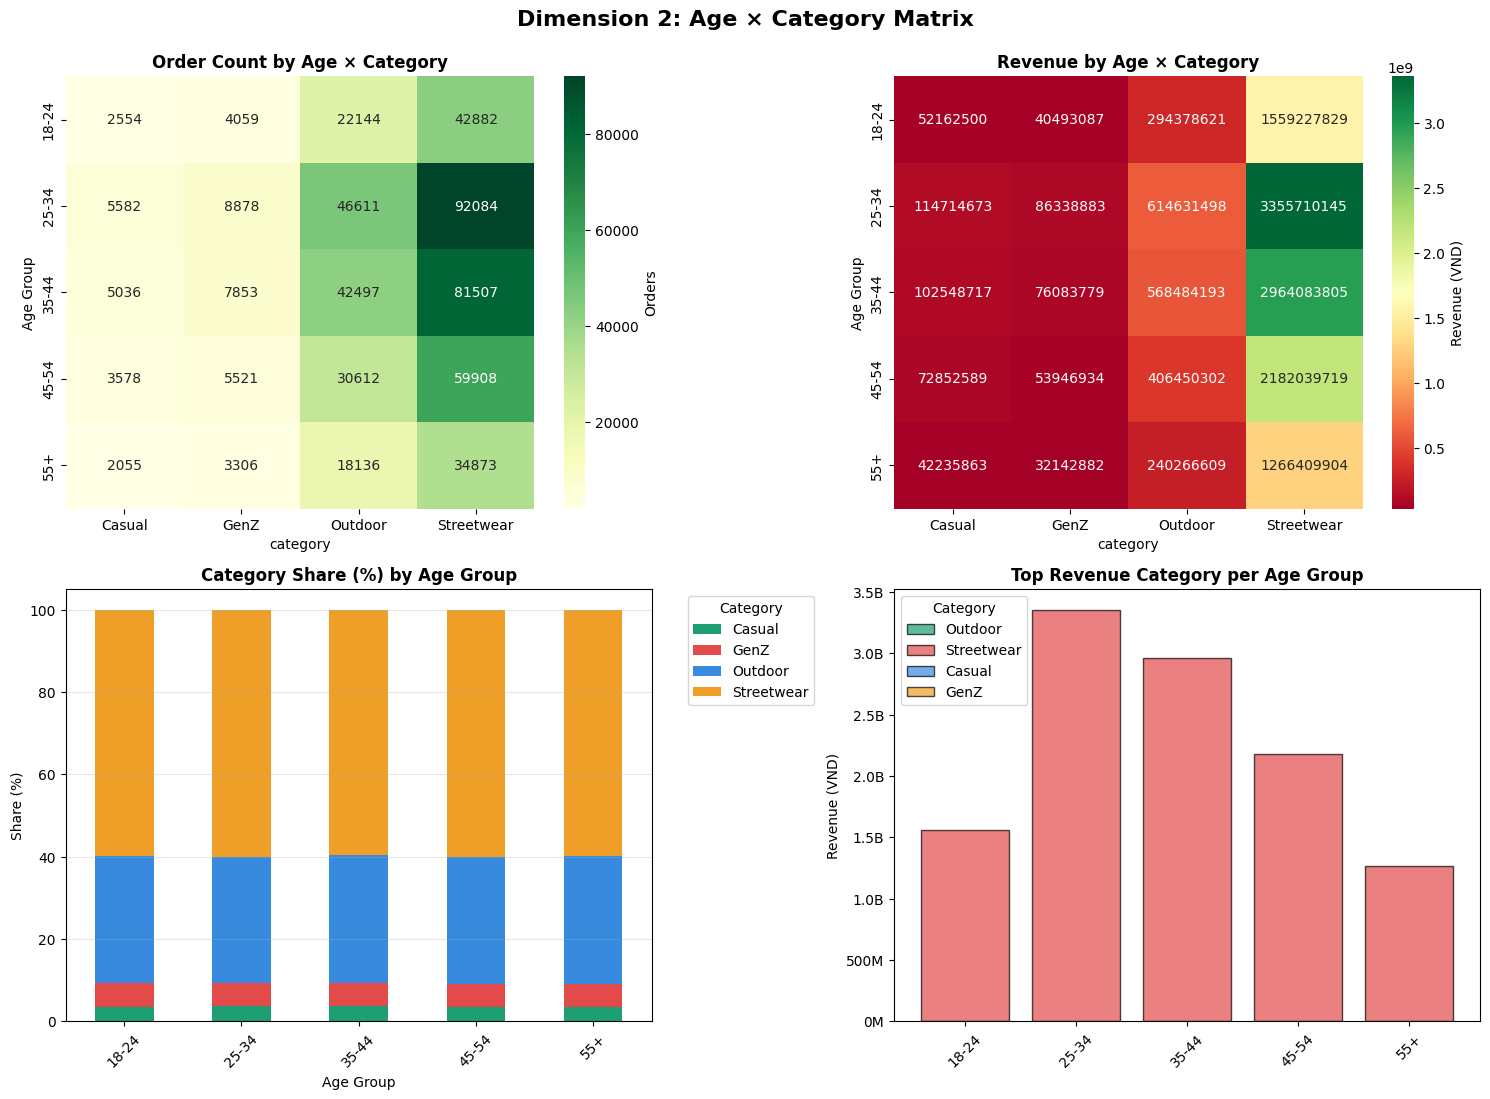


📊 DIMENSION 2: AGE × CATEGORY MATRIX - METRICS CALCULATIONS

Metrics computed:
--------------------------------------------------------------------------------

1. Order Count by Age × Category
   Formula: COUNT(DISTINCT order_id) GROUP BY age_group, category
   Meaning: Number of orders for each age-category combination

2. Revenue by Age × Category
   Formula: SUM(price × quantity) GROUP BY age_group, category
   Meaning: Total revenue from each age-category combination

3. Category Share % within Age Group
   Formula: (Orders in category / Total orders in age_group) × 100
   Meaning: What % of each age group's orders come from each category

4. Top Category per Age Group
   Formula: MAX(Revenue) per age_group
   Meaning: Which category generates the highest revenue for each age group

--------------------------------------------------------------------------------
📈 Order Count by Age × Category:
--------------------------------------------------------------------------------
categ

In [7]:
# Dimension 2: Age × Category Matrix
# Create pivot tables for volume and revenue
age_cat_volume = order_items_delivered.groupby(['age_group', 'category']).agg(
    order_count = ('order_id', 'nunique'),
    quantity = ('quantity', 'sum'),
    revenue = ('price', lambda x: (x * order_items_delivered.loc[x.index, 'quantity']).sum())
).reset_index()

age_cat_volume['age_group'] = pd.Categorical(age_cat_volume['age_group'], categories=age_order, ordered=True)
age_cat_volume = age_cat_volume.sort_values(['age_group', 'revenue'], ascending=[True, False])

# Pivot for heatmaps
pivot_volume = age_cat_volume.pivot(index='age_group', columns='category', values='order_count').fillna(0)
pivot_revenue = age_cat_volume.pivot(index='age_group', columns='category', values='revenue').fillna(0)

# Calculate category share within each age group
category_share_per_age = age_cat_volume.pivot(index='age_group', columns='category', values='order_count').fillna(0)
category_share_per_age = category_share_per_age.div(category_share_per_age.sum(axis=1), axis=0) * 100

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle('Dimension 2: Age × Category Matrix', fontsize=16, fontweight='bold', y=0.995)

# Plot 1: Volume Heatmap (Order Count)
ax1 = axes[0, 0]
sns.heatmap(pivot_volume, annot=True, fmt='.0f', cmap='YlGn', ax=ax1, cbar_kws={'label': 'Orders'})
ax1.set_title('Order Count by Age × Category', fontweight='bold')
ax1.set_ylabel('Age Group')

# Plot 2: Revenue Heatmap
ax2 = axes[0, 1]
sns.heatmap(pivot_revenue, annot=True, fmt='.0f', cmap='RdYlGn', ax=ax2, cbar_kws={'label': 'Revenue (VND)'})
ax2.set_title('Revenue by Age × Category', fontweight='bold')
ax2.set_ylabel('Age Group')

# Plot 3: Category Share % within each Age Group
ax3 = axes[1, 0]
category_share_per_age.plot(kind='bar', stacked=True, ax=ax3, 
                            color=['#1D9E75', '#E24B4A', '#378ADD', '#EF9F27'])
ax3.set_title('Category Share (%) by Age Group', fontweight='bold')
ax3.set_ylabel('Share (%)')
ax3.set_xlabel('Age Group')
ax3.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
ax3.set_xticklabels(ax3.get_xticklabels(), rotation=45)
ax3.grid(axis='y', alpha=0.3)

# Plot 4: Top category per age group
ax4 = axes[1, 1]
top_category_per_age = age_cat_volume.loc[age_cat_volume.groupby('age_group')['revenue'].idxmax()]
top_category_per_age['age_group'] = pd.Categorical(top_category_per_age['age_group'], categories=age_order, ordered=True)
top_category_per_age = top_category_per_age.sort_values('age_group')

category_colors_map = {'Outdoor': '#1D9E75', 'Streetwear': '#E24B4A', 'Casual': '#378ADD', 'GenZ': '#EF9F27'}
bar_colors = [category_colors_map.get(cat, '#888') for cat in top_category_per_age['category']]

ax4.bar(range(len(top_category_per_age)), top_category_per_age['revenue'], color=bar_colors, alpha=0.7, edgecolor='black')
ax4.set_xticks(range(len(top_category_per_age)))
ax4.set_xticklabels(top_category_per_age['age_group'], rotation=45)
ax4.set_title('Top Revenue Category per Age Group', fontweight='bold')
ax4.set_ylabel('Revenue (VND)')
ax4.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x/1e9:.1f}B' if x >= 1e9 else f'{x/1e6:.0f}M'))

# Add legend for colors
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color, alpha=0.7, edgecolor='black', label=cat) 
                   for cat, color in category_colors_map.items()]
ax4.legend(handles=legend_elements, title='Category', loc='upper left')

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("📊 DIMENSION 2: AGE × CATEGORY MATRIX - METRICS CALCULATIONS")
print("="*80)
print("\nMetrics computed:")
print("-" * 80)
print("\n1. Order Count by Age × Category")
print("   Formula: COUNT(DISTINCT order_id) GROUP BY age_group, category")
print("   Meaning: Number of orders for each age-category combination")
print()
print("2. Revenue by Age × Category")
print("   Formula: SUM(price × quantity) GROUP BY age_group, category")
print("   Meaning: Total revenue from each age-category combination")
print()
print("3. Category Share % within Age Group")
print("   Formula: (Orders in category / Total orders in age_group) × 100")
print("   Meaning: What % of each age group's orders come from each category")
print()
print("4. Top Category per Age Group")
print("   Formula: MAX(Revenue) per age_group")
print("   Meaning: Which category generates the highest revenue for each age group")
print("\n" + "-" * 80)
print("📈 Order Count by Age × Category:")
print("-" * 80)
print(pivot_volume.to_string())
print("\n" + "-" * 80)
print("💰 Revenue by Age × Category:")
print("-" * 80)
print(pivot_revenue.to_string())
print("\n" + "-" * 80)
print("📊 Category Share (%) within Each Age Group:")
print("-" * 80)
print(category_share_per_age.round(1).to_string())
print("\n" + "-" * 80)
print("🏆 Top Category per Age Group:")
print("-" * 80)
print(top_category_per_age[['age_group', 'category', 'revenue', 'order_count']].to_string(index=False))
print("="*80 + "\n")

# 3️⃣ WEB TRAFFIC ATTRIBUTION & CUSTOMER ACQUISITION
**Objective:** Which traffic sources convert best and attract which customer segments

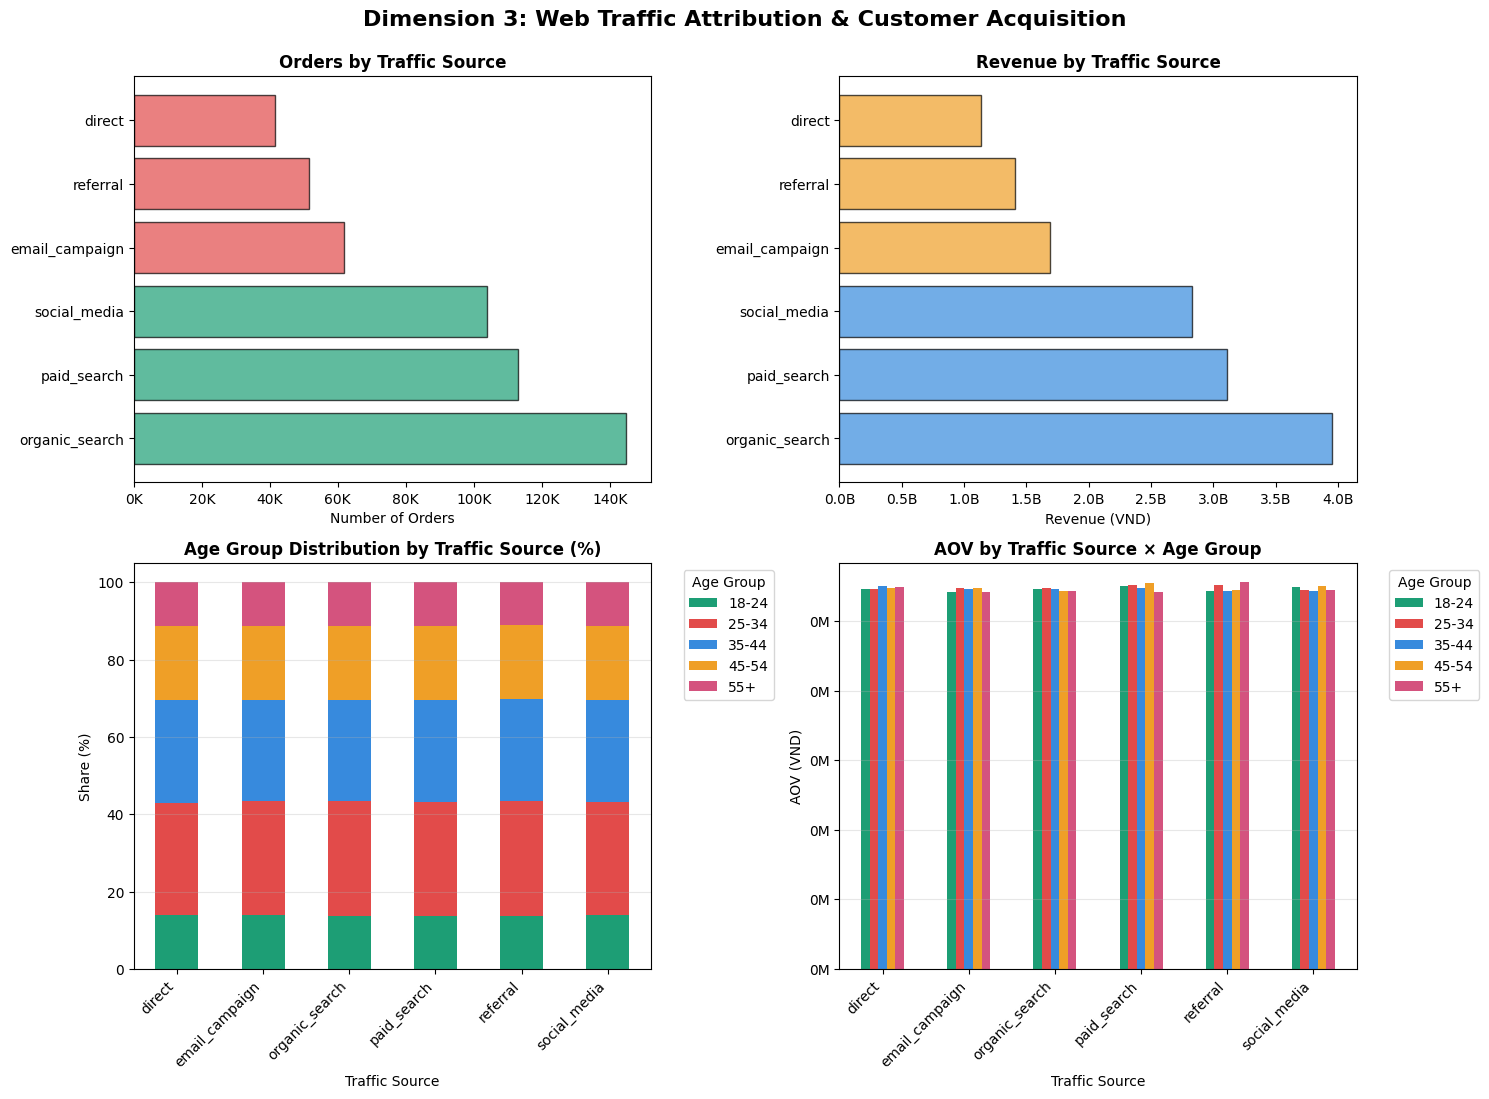


📊 DIMENSION 3: WEB TRAFFIC ATTRIBUTION & CUSTOMER ACQUISITION - METRICS

Metrics computed:
--------------------------------------------------------------------------------

1. Orders by Traffic Source
   Formula: COUNT(DISTINCT order_id) GROUP BY order_source
   Meaning: Number of orders from each traffic source

2. Revenue by Traffic Source
   Formula: SUM(price × quantity) GROUP BY order_source
   Meaning: Total revenue from each traffic source

3. Age Group Distribution per Traffic Source (%)
   Formula: (Orders in age_group / Total orders in source) × 100
   Meaning: What % of each traffic source comes from each age group

4. AOV by Traffic Source × Age Group
   Formula: Total Revenue / Order Count GROUP BY order_source, age_group
   Meaning: Average order value for each source-age combination

--------------------------------------------------------------------------------
📈 Orders & Revenue by Traffic Source:
----------------------------------------------------------------------

In [9]:
# Dimension 3: Web Traffic Attribution & Customer Acquisition
# Build a clean transaction-level base with source, age, quantity and revenue
traffic_base = order_items_delivered.copy()
traffic_base['line_revenue'] = traffic_base['price'] * traffic_base['quantity']

# Orders and revenue by traffic source
source_summary = traffic_base.groupby('order_source').agg(
    orders=('order_id', 'nunique'),
    revenue=('line_revenue', 'sum')
).sort_values('orders', ascending=False)
source_summary['aov'] = source_summary['revenue'] / source_summary['orders']

# Orders, revenue and AOV by traffic source x age group
traffic_revenue_detail = traffic_base.groupby(['order_source', 'age_group']).agg(
    order_count=('order_id', 'nunique'),
    revenue=('line_revenue', 'sum')
).reset_index()
traffic_revenue_detail['aov'] = traffic_revenue_detail['revenue'] / traffic_revenue_detail['order_count']

# Age distribution per traffic source
source_age_dist = orders_delivered.groupby(['order_source', 'age_group'])['order_id'].nunique().unstack(fill_value=0)
source_age_dist_pct = source_age_dist.div(source_age_dist.sum(axis=1), axis=0) * 100
source_age_dist_pct = source_age_dist_pct.reindex(columns=age_order)

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle('Dimension 3: Web Traffic Attribution & Customer Acquisition', fontsize=16, fontweight='bold', y=0.995)

ax1 = axes[0, 0]
colors = ['#1D9E75' if x > source_summary['orders'].median() else '#E24B4A' for x in source_summary['orders']]
ax1.barh(source_summary.index, source_summary['orders'], color=colors, alpha=0.7, edgecolor='black')
ax1.set_title('Orders by Traffic Source', fontweight='bold')
ax1.set_xlabel('Number of Orders')
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x/1e6:.1f}M' if x >= 1e6 else f'{x/1e3:.0f}K'))

ax2 = axes[0, 1]
colors = ['#378ADD' if x > source_summary['revenue'].median() else '#EF9F27' for x in source_summary['revenue']]
ax2.barh(source_summary.index, source_summary['revenue'], color=colors, alpha=0.7, edgecolor='black')
ax2.set_title('Revenue by Traffic Source', fontweight='bold')
ax2.set_xlabel('Revenue (VND)')
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x/1e9:.1f}B'))

ax3 = axes[1, 0]
source_age_dist_pct.plot(kind='bar', stacked=True, ax=ax3, color=['#1D9E75', '#E24B4A', '#378ADD', '#EF9F27', '#D4537E'])
ax3.set_title('Age Group Distribution by Traffic Source (%)', fontweight='bold')
ax3.set_ylabel('Share (%)')
ax3.set_xlabel('Traffic Source')
ax3.legend(title='Age Group', bbox_to_anchor=(1.05, 1), loc='upper left')
ax3.set_xticklabels(ax3.get_xticklabels(), rotation=45, ha='right')
ax3.grid(axis='y', alpha=0.3)

ax4 = axes[1, 1]
aov_pivot = traffic_revenue_detail.pivot(index='order_source', columns='age_group', values='aov').fillna(0)
aov_pivot = aov_pivot.reindex(columns=age_order)
aov_pivot.plot(kind='bar', ax=ax4, color=['#1D9E75', '#E24B4A', '#378ADD', '#EF9F27', '#D4537E'])
ax4.set_title('AOV by Traffic Source × Age Group', fontweight='bold')
ax4.set_ylabel('AOV (VND)')
ax4.set_xlabel('Traffic Source')
ax4.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x/1e6:.0f}M'))
ax4.legend(title='Age Group', bbox_to_anchor=(1.05, 1), loc='upper left')
ax4.set_xticklabels(ax4.get_xticklabels(), rotation=45, ha='right')
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("📊 DIMENSION 3: WEB TRAFFIC ATTRIBUTION & CUSTOMER ACQUISITION - METRICS")
print("="*80)
print("\nMetrics computed:")
print("-" * 80)
print("\n1. Orders by Traffic Source")
print("   Formula: COUNT(DISTINCT order_id) GROUP BY order_source")
print("   Meaning: Number of orders from each traffic source")
print()
print("2. Revenue by Traffic Source")
print("   Formula: SUM(price × quantity) GROUP BY order_source")
print("   Meaning: Total revenue from each traffic source")
print()
print("3. Age Group Distribution per Traffic Source (%)")
print("   Formula: (Orders in age_group / Total orders in source) × 100")
print("   Meaning: What % of each traffic source comes from each age group")
print()
print("4. AOV by Traffic Source × Age Group")
print("   Formula: Total Revenue / Order Count GROUP BY order_source, age_group")
print("   Meaning: Average order value for each source-age combination")
print("\n" + "-" * 80)
print("📈 Orders & Revenue by Traffic Source:")
print("-" * 80)
print(source_summary.to_string())
print("\n" + "-" * 80)
print("👥 Age Distribution (%) by Traffic Source:")
print("-" * 80)
print(source_age_dist_pct.round(1).to_string())
print("\n" + "-" * 80)
print("💸 AOV by Traffic Source × Age Group:")
print("-" * 80)
print(traffic_revenue_detail[['order_source', 'age_group', 'order_count', 'revenue', 'aov']].to_string(index=False))
print("="*80 + "\n")

# 4️⃣ REGION × CATEGORY PREFERENCES
**Objective:** Geographic flavor preferences (East, Central, South/West regions)

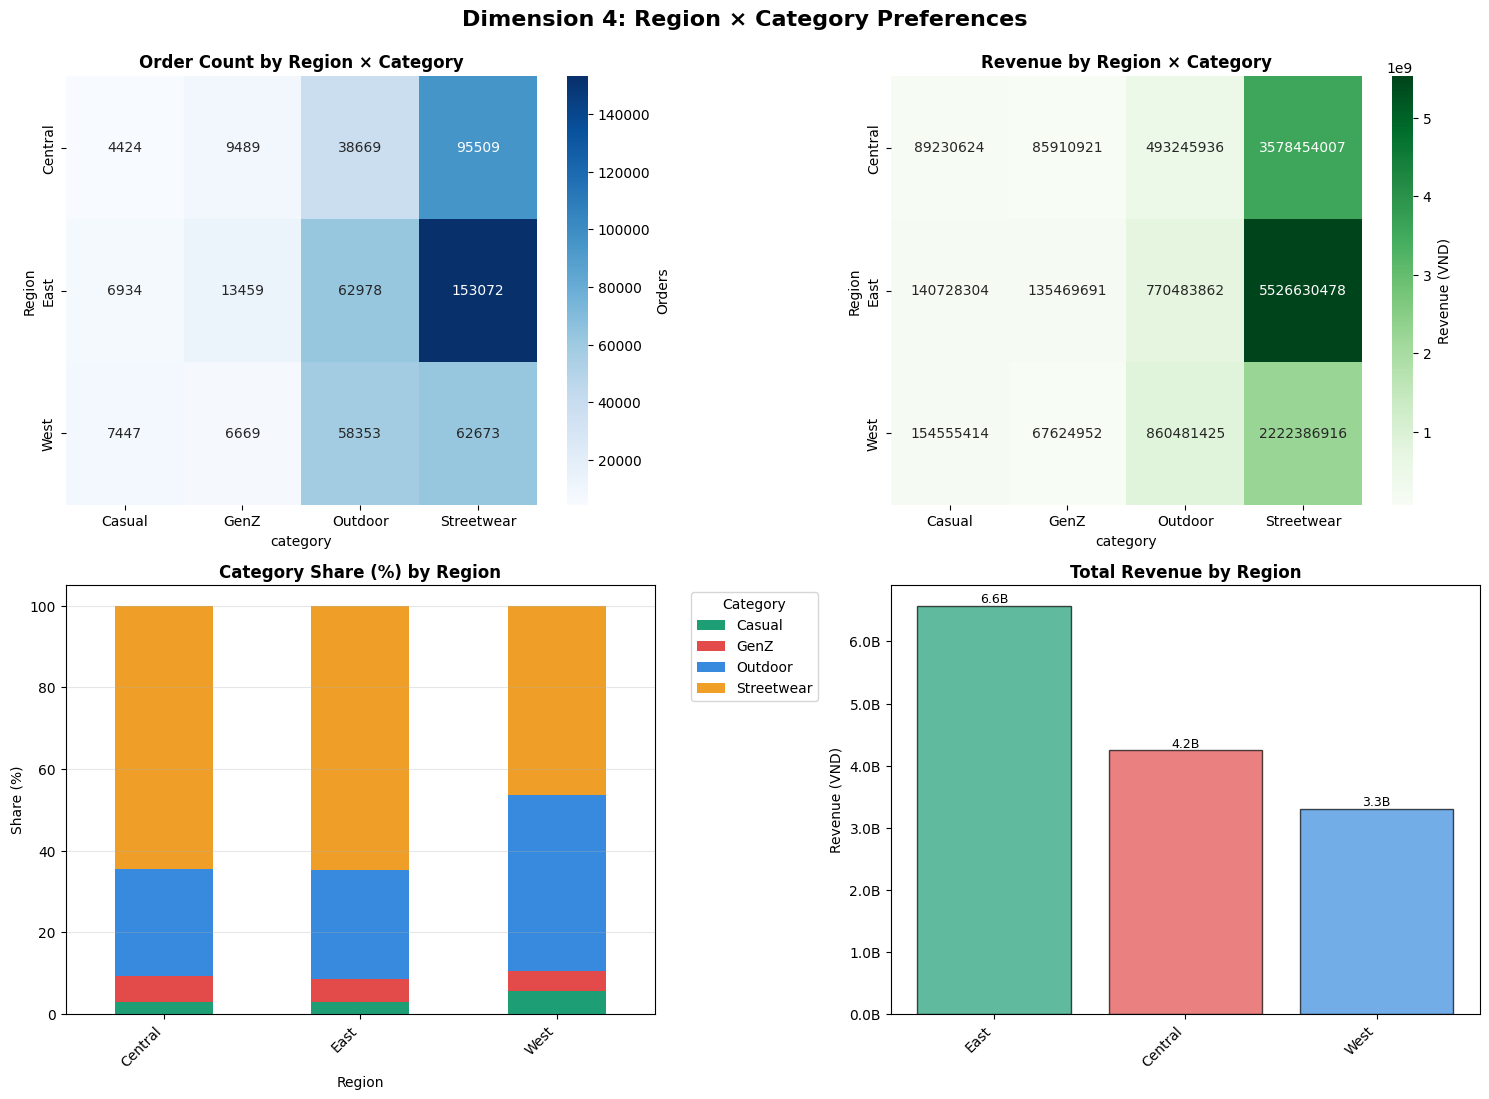


📊 DIMENSION 4: REGION × CATEGORY PREFERENCES - METRICS CALCULATIONS

Metrics computed:
--------------------------------------------------------------------------------

1. Order Count by Region × Category
   Formula: COUNT(DISTINCT order_id) GROUP BY region, category
   Meaning: Number of orders for each region-category combination

2. Revenue by Region × Category
   Formula: SUM(price × quantity) GROUP BY region, category
   Meaning: Total revenue from each region-category combination

3. Category Share (%) by Region
   Formula: (Orders in category / Total orders in region) × 100
   Meaning: What % of each region's orders come from each category

4. Total Revenue by Region
   Formula: SUM(Revenue) GROUP BY region
   Meaning: Total revenue contribution from each region

--------------------------------------------------------------------------------
📈 Order Count by Region × Category:
--------------------------------------------------------------------------------
category  Casual   G

In [10]:
# Dimension 4: Region × Category Preferences
# Create pivot tables
region_cat_data = order_items_delivered.groupby(['region', 'category']).agg(
    order_count = ('order_id', 'nunique'),
    quantity = ('quantity', 'sum'),
    revenue = ('price', lambda x: (x * order_items_delivered.loc[x.index, 'quantity']).sum())
).reset_index()

region_cat_data = region_cat_data.dropna(subset=['region'])  # Remove NaN regions

# Pivot for visualizations
pivot_region_volume = region_cat_data.pivot(index='region', columns='category', values='order_count').fillna(0)
pivot_region_revenue = region_cat_data.pivot(index='region', columns='category', values='revenue').fillna(0)

# Calculate category share within each region
category_share_per_region = pivot_region_volume.div(pivot_region_volume.sum(axis=1), axis=0) * 100

# Find top category per region
top_cat_per_region = region_cat_data.loc[region_cat_data.groupby('region')['revenue'].idxmax()]

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle('Dimension 4: Region × Category Preferences', fontsize=16, fontweight='bold', y=0.995)

# Plot 1: Volume Heatmap
ax1 = axes[0, 0]
sns.heatmap(pivot_region_volume, annot=True, fmt='.0f', cmap='Blues', ax=ax1, cbar_kws={'label': 'Orders'})
ax1.set_title('Order Count by Region × Category', fontweight='bold')
ax1.set_ylabel('Region')

# Plot 2: Revenue Heatmap
ax2 = axes[0, 1]
sns.heatmap(pivot_region_revenue, annot=True, fmt='.0f', cmap='Greens', ax=ax2, cbar_kws={'label': 'Revenue (VND)'})
ax2.set_title('Revenue by Region × Category', fontweight='bold')
ax2.set_ylabel('Region')

# Plot 3: Category Share (%) by Region (Stacked Bar)
ax3 = axes[1, 0]
category_share_per_region.plot(kind='bar', stacked=True, ax=ax3,
                               color=['#1D9E75', '#E24B4A', '#378ADD', '#EF9F27'])
ax3.set_title('Category Share (%) by Region', fontweight='bold')
ax3.set_ylabel('Share (%)')
ax3.set_xlabel('Region')
ax3.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
ax3.set_xticklabels(ax3.get_xticklabels(), rotation=45, ha='right')
ax3.grid(axis='y', alpha=0.3)

# Plot 4: Revenue by Region
ax4 = axes[1, 1]
region_revenue_total = region_cat_data.groupby('region')['revenue'].sum().sort_values(ascending=False)
colors = ['#1D9E75', '#E24B4A', '#378ADD'][:len(region_revenue_total)]
ax4.bar(range(len(region_revenue_total)), region_revenue_total.values, color=colors, alpha=0.7, edgecolor='black')
ax4.set_xticks(range(len(region_revenue_total)))
ax4.set_xticklabels(region_revenue_total.index, rotation=45, ha='right')
ax4.set_title('Total Revenue by Region', fontweight='bold')
ax4.set_ylabel('Revenue (VND)')
ax4.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x/1e12:.1f}T' if x >= 1e12 else f'{x/1e9:.1f}B'))
for i, val in enumerate(region_revenue_total.values):
    ax4.text(i, val, f'{val/1e12:.2f}T' if val >= 1e12 else f'{val/1e9:.1f}B', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("📊 DIMENSION 4: REGION × CATEGORY PREFERENCES - METRICS CALCULATIONS")
print("="*80)
print("\nMetrics computed:")
print("-" * 80)
print("\n1. Order Count by Region × Category")
print("   Formula: COUNT(DISTINCT order_id) GROUP BY region, category")
print("   Meaning: Number of orders for each region-category combination")
print()
print("2. Revenue by Region × Category")
print("   Formula: SUM(price × quantity) GROUP BY region, category")
print("   Meaning: Total revenue from each region-category combination")
print()
print("3. Category Share (%) by Region")
print("   Formula: (Orders in category / Total orders in region) × 100")
print("   Meaning: What % of each region's orders come from each category")
print()
print("4. Total Revenue by Region")
print("   Formula: SUM(Revenue) GROUP BY region")
print("   Meaning: Total revenue contribution from each region")
print("\n" + "-" * 80)
print("📈 Order Count by Region × Category:")
print("-" * 80)
print(pivot_region_volume.to_string())
print("\n" + "-" * 80)
print("💰 Revenue by Region × Category:")
print("-" * 80)
print(pivot_region_revenue.to_string())
print("\n" + "-" * 80)
print("📊 Category Share (%) by Region:")
print("-" * 80)
print(category_share_per_region.round(1).to_string())
print("\n" + "-" * 80)
print("🏆 Top Category by Region:")
print("-" * 80)
print(top_cat_per_region[['region', 'category', 'revenue', 'order_count']].to_string(index=False))
print("="*80 + "\n")

# 5️⃣ SEASONALITY BY AGE GROUP
**Objective:** Do different age cohorts respond to seasonal trends differently?

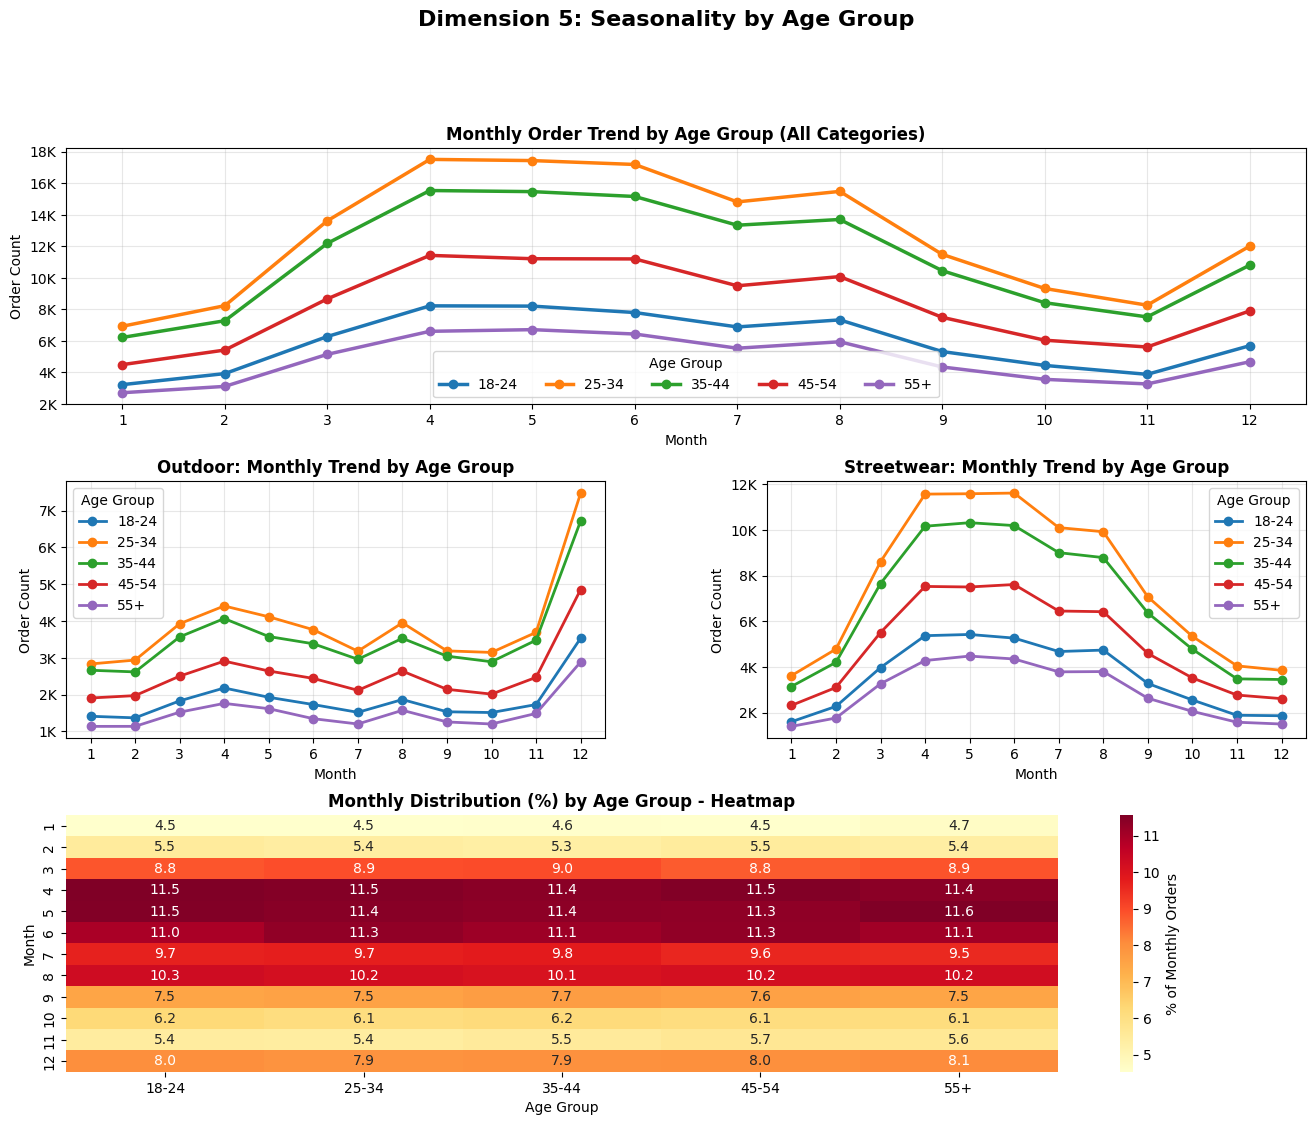


📊 DIMENSION 5: SEASONALITY BY AGE GROUP - METRICS CALCULATIONS

Metrics computed:
--------------------------------------------------------------------------------

1. Monthly Order Count by Age Group
   Formula: COUNT(DISTINCT order_id) GROUP BY month, age_group
   Meaning: How many orders each age group places each month

2. Monthly Distribution (%) by Age Group
   Formula: (Orders in month / Total orders in age_group) × 100
   Meaning: What % of each age group's annual orders come from each month

3. Outdoor/Streetwear Monthly Trend by Age Group
   Formula: COUNT(DISTINCT order_id) GROUP BY month, age_group, category
   Meaning: Seasonal pattern for specific categories by age cohort

4. Peak Month Detection
   Formula: MAX(order_count) per age_group per category
   Meaning: Which month is busiest for each age group × category combo

--------------------------------------------------------------------------------
📈 Monthly Order Count by Age Group (All Categories):
------------------

In [11]:
# Dimension 5: Seasonality by Age Group
# Calculate monthly volume by age group and category
seasonality_data = order_items_delivered.groupby(['month', 'age_group', 'category']).agg(
    order_count = ('order_id', 'nunique'),
    quantity = ('quantity', 'sum'),
    revenue = ('price', lambda x: (x * order_items_delivered.loc[x.index, 'quantity']).sum())
).reset_index()

# Also get monthly trend by age group (overall)
seasonality_by_age = order_items_delivered.groupby(['month', 'age_group']).agg(
    order_count = ('order_id', 'nunique'),
    quantity = ('quantity', 'sum'),
    revenue = ('price', lambda x: (x * order_items_delivered.loc[x.index, 'quantity']).sum())
).reset_index()

# Calculate monthly percentage per age group
monthly_pct_by_age = seasonality_by_age.pivot(index='month', columns='age_group', values='order_count').fillna(0)
for col in monthly_pct_by_age.columns:
    monthly_pct_by_age[col] = (monthly_pct_by_age[col] / monthly_pct_by_age[col].sum()) * 100

# Focus on Outdoor & Streetwear seasonality by age
outdoor_data = seasonality_data[seasonality_data['category'] == 'Outdoor'].copy()
streetwear_data = seasonality_data[seasonality_data['category'] == 'Streetwear'].copy()

outdoor_by_month_age = outdoor_data.groupby(['month', 'age_group'])['order_count'].sum().unstack(fill_value=0)
streetwear_by_month_age = streetwear_data.groupby(['month', 'age_group'])['order_count'].sum().unstack(fill_value=0)

# Visualization
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)
fig.suptitle('Dimension 5: Seasonality by Age Group', fontsize=16, fontweight='bold', y=0.995)

# Plot 1: Overall Monthly Trend by Age Group
ax1 = fig.add_subplot(gs[0, :])
for age in age_order:
    if age in seasonality_by_age['age_group'].unique():
        data = seasonality_by_age[seasonality_by_age['age_group'] == age]
        ax1.plot(data['month'], data['order_count'], marker='o', linewidth=2.5, label=age)
ax1.set_title('Monthly Order Trend by Age Group (All Categories)', fontweight='bold')
ax1.set_xlabel('Month')
ax1.set_ylabel('Order Count')
ax1.set_xticks(range(1, 13))
ax1.legend(title='Age Group', ncol=5)
ax1.grid(True, alpha=0.3)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x/1e3:.0f}K'))

# Plot 2: Outdoor Category - Monthly Trend by Age Group
ax2 = fig.add_subplot(gs[1, 0])
for age in age_order:
    if age in outdoor_by_month_age.columns:
        ax2.plot(outdoor_by_month_age.index, outdoor_by_month_age[age], marker='o', linewidth=2, label=age)
ax2.set_title('Outdoor: Monthly Trend by Age Group', fontweight='bold')
ax2.set_xlabel('Month')
ax2.set_ylabel('Order Count')
ax2.set_xticks(range(1, 13))
ax2.legend(title='Age Group')
ax2.grid(True, alpha=0.3)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x/1e3:.0f}K'))

# Plot 3: Streetwear Category - Monthly Trend by Age Group
ax3 = fig.add_subplot(gs[1, 1])
for age in age_order:
    if age in streetwear_by_month_age.columns:
        ax3.plot(streetwear_by_month_age.index, streetwear_by_month_age[age], marker='o', linewidth=2, label=age)
ax3.set_title('Streetwear: Monthly Trend by Age Group', fontweight='bold')
ax3.set_xlabel('Month')
ax3.set_ylabel('Order Count')
ax3.set_xticks(range(1, 13))
ax3.legend(title='Age Group')
ax3.grid(True, alpha=0.3)
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x/1e3:.0f}K'))

# Plot 4: Heatmap - Monthly % Distribution by Age Group
ax4 = fig.add_subplot(gs[2, :])
sns.heatmap(monthly_pct_by_age, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax4, cbar_kws={'label': '% of Monthly Orders'})
ax4.set_title('Monthly Distribution (%) by Age Group - Heatmap', fontweight='bold')
ax4.set_xlabel('Age Group')
ax4.set_ylabel('Month')

plt.tight_layout()
plt.show()

# Detailed seasonality analysis
print("\n" + "="*80)
print("📊 DIMENSION 5: SEASONALITY BY AGE GROUP - METRICS CALCULATIONS")
print("="*80)
print("\nMetrics computed:")
print("-" * 80)
print("\n1. Monthly Order Count by Age Group")
print("   Formula: COUNT(DISTINCT order_id) GROUP BY month, age_group")
print("   Meaning: How many orders each age group places each month")
print()
print("2. Monthly Distribution (%) by Age Group")
print("   Formula: (Orders in month / Total orders in age_group) × 100")
print("   Meaning: What % of each age group's annual orders come from each month")
print()
print("3. Outdoor/Streetwear Monthly Trend by Age Group")
print("   Formula: COUNT(DISTINCT order_id) GROUP BY month, age_group, category")
print("   Meaning: Seasonal pattern for specific categories by age cohort")
print()
print("4. Peak Month Detection")
print("   Formula: MAX(order_count) per age_group per category")
print("   Meaning: Which month is busiest for each age group × category combo")
print("\n" + "-" * 80)
print("📈 Monthly Order Count by Age Group (All Categories):")
print("-" * 80)
monthly_summary = seasonality_by_age.pivot(index='month', columns='age_group', values='order_count').fillna(0)
monthly_summary = monthly_summary.reindex(age_order, axis=1)
print(monthly_summary.to_string())

# Find peak months for each age group
print("\n" + "-" * 80)
print("🏆 Peak Month per Age Group:")
print("-" * 80)
for age in age_order:
    age_data = seasonality_by_age[seasonality_by_age['age_group'] == age]
    if not age_data.empty:
        peak_month = age_data.loc[age_data['order_count'].idxmax(), 'month']
        peak_count = age_data.loc[age_data['order_count'].idxmax(), 'order_count']
        print(f"  {age:8s} → Month {int(peak_month):2d} (Orders: {peak_count:,.0f})")

# Seasonality index for Outdoor and Streetwear
print("\n" + "-" * 80)
print("📌 Key Insight: Outdoor vs Streetwear Seasonality by Age")
print("-" * 80)
for age in age_order:
    outdoor_data_age = outdoor_data[outdoor_data['age_group'] == age]
    streetwear_data_age = streetwear_data[streetwear_data['age_group'] == age]
    
    if not outdoor_data_age.empty and not streetwear_data_age.empty:
        outdoor_peak_month = outdoor_data_age.loc[outdoor_data_age['order_count'].idxmax(), 'month']
        streetwear_peak_month = streetwear_data_age.loc[streetwear_data_age['order_count'].idxmax(), 'month']
        outdoor_total = outdoor_data_age['order_count'].sum()
        streetwear_total = streetwear_data_age['order_count'].sum()
        
        print(f"\n  {age}:")
        print(f"    Outdoor: Peak Month {int(outdoor_peak_month):2d}, Total Orders: {outdoor_total:,.0f}")
        print(f"    Streetwear: Peak Month {int(streetwear_peak_month):2d}, Total Orders: {streetwear_total:,.0f}")

print("="*80 + "\n")